## Tarea 1: Repaso básicos de ML — material de práctica (no calificado)

Esta tarea **ya no se entrega ni se califica**. Es material de práctica y preparación: los exámenes evalúan la teoría detrás de estos experimentos (temarios en `Examenes/`) y el proyecto de colaboración con IA usa este mismo protocolo experimental.

Sugerencias para sacarle provecho:
1. Puedes usar LLMs o agentes de IA libremente — de hecho es buen entrenamiento para el proyecto final. Pero recuerda: los exámenes son en clase y a mano, evalúan que *tú* entiendas.
2. Antes de correr cada experimento, escribe qué esperas observar y por qué; después compara con lo que obtuviste.
3. Asegúrate de entender cada línea del código (tuyo o del agente); consulta la documentación de PyTorch.
4. Mantén el protocolo experimental del curso: semilla fija, mismos splits, un factor variado a la vez, curvas + tabla resumen + interpretación.

Las siguientes preguntas son de implementación utilizando el notebook que tenemos de Intro_Pytorch. 

1. Regresión lineal desde cero: 

    a. Define un modelo lineal utilizando `nn.Linear(1,1)` y entrena utilizando la función `synthetic_regression_data` del notebook

    b. Con los mismo datos, define un modelo utilizando la `LinearRegression` que nosotros generamos

    c. Compara los resultados que generan estas dos. ¿Cuál es la diferencia? 

2. Batch vs. Minibatch:
    
    a. Entrena con `batch_size = n` (el ejemplo del notebook) con batch_size = 16, 32  y 64

    b. Grafica la pérdida por época en los tres casos y comenta las diferencias en estabilidad y velocidad de convergencia.

3. Closed-form vs. GD:
    
    a. Usa `torch.linalg.lstsq` o la fórmula cerrada para obtener w y b

    b. Compara sus valores con los aprendidos por GD tras converger (misma escala y ruido).

4. Decay de la learning rate:

    a. Usa `torch.optim.lr_scheduler.StepLR` con step = 100 epochs, γ = 0.1.
    b. Registra la lr en cada época y muéstrala junto a la pérdida para ver el efecto del decaimiento.

## Ejercicio 1

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt

#### A mano

In [2]:
def synthetic_regression_data(w, b, num_samples = 1000):
    
    num_inputs = w.shape[0]
    X = torch.randn(num_samples, num_inputs)
    y = X @ w.reshape(-1, 1) + b
    y += torch.randn_like(y) * 0.01

    return X, y

In [3]:
SEED = 42
torch.manual_seed(SEED)

true_w = torch.tensor([2.0])
true_b = 4.2
X, y = synthetic_regression_data(true_w, true_b)

In [4]:
class LinearRegression(nn.Module):
    def __init__(self, num_inputs, lr, sigma = 0.01):
        super(LinearRegression, self).__init__()

        self.num_inputs = num_inputs
        self.lr = lr
        self.sigma = sigma

        self.w =  nn.Parameter(
            torch.normal(0.0, sigma, size = (num_inputs, 1))
        )
        self.b = nn.Parameter(
            torch.zeros(1)
        )

    def forward(self, X):

        return torch.matmul(X, self.w) + self.b

    def loss(self, y_hat, y):

        l = (y_hat - y)**2 / 2

        return l.mean()

    def configure_optimizers(self):

        return SGD([self.w, self.b], self.lr)

In [5]:
class SGD:
    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr
    
    def step(self):
        for p in self.params:
            p.data -= self.lr * p.grad
    
    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

In [6]:
dataset =  TensorDataset(X, y)

train_size = int(0.8 * len(dataset))
val_size =  len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size], generator = torch.Generator().manual_seed(SEED)
)

In [7]:
batch_size = 32

train_loader = DataLoader (train_dataset, batch_size = batch_size, shuffle = True)
val_loader =  DataLoader(val_dataset, batch_size = batch_size, shuffle = False)

In [8]:
torch.manual_seed(SEED)
model = LinearRegression(num_inputs = X.shape[1], lr = 0.03)
optim = model.configure_optimizers()

Error en w:  tensor([0.0009])
Error en b:  tensor([0.0024])


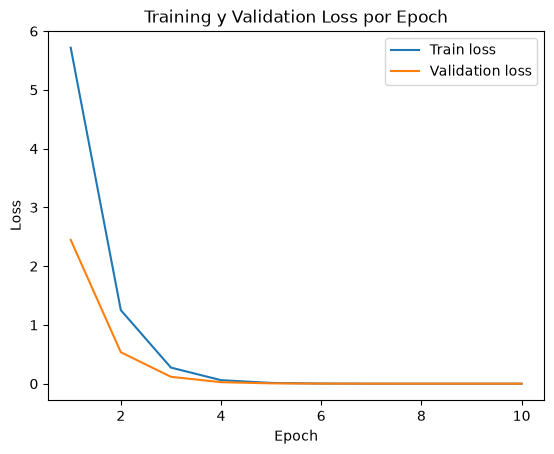

In [9]:
torch.manual_seed(SEED)  # mismo orden de shuffle en ambas corridas

num_epochs = 10

train_losses, val_losses = [], []

for epoch in range(1, num_epochs +1):
    # Fase de entrenamiento
    model.train()
    total_train, count_train = 0.0, 0
    for Xb, yb in train_loader:
        y_hat = model(Xb)
        loss = model.loss(y_hat, yb)
        optim.zero_grad()
        loss.backward()
        optim.step()
        total_train += loss.item() * yb.shape[0]
        count_train += yb.shape[0]

    train_losses.append(total_train / count_train)

    # Fase de  validación
    model.eval()
    total_val, count_val = 0.0, 0
    with torch.no_grad():
        for Xv, yv in val_loader:
            loss_val = model.loss(model(Xv), yv)
            total_val += loss_val.item() * yv.shape[0]
            count_val += yv.shape[0]

    val_losses.append(total_val / count_val)

# Evaluación final de los parámetroos aprendidos 

with torch.no_grad():
    est_w = model.w.reshape(true_w.shape)
    est_b = model.b
    print("Error en w: ", true_w - est_w)
    print("Error en b: ", true_b - est_b)

# Graficar pérdidas
plt.plot(range(1, num_epochs + 1), train_losses, label='Train loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training y Validation Loss por Epoch')
plt.show()

#### Usando `nn.Linear`

In [10]:
torch.manual_seed(SEED)
model_nn = nn.Linear(in_features = X.shape[1], out_features = 1)

# Misma inicializacion que LinearRegression: w ~ N(0, 0.01), b = 0
nn.init.normal_(model_nn.weight, mean = 0.0, std = 0.01)
nn.init.zeros_(model_nn.bias)

optim_nn = torch.optim.SGD(model_nn.parameters(), lr = 0.03)

# nn.MSELoss es (y_hat - y)^2; dividimos entre 2 para igualar la perdida de LinearRegression
mse = nn.MSELoss()
loss_fn = lambda y_hat, y: mse(y_hat, y) / 2


Error en w:  tensor([0.0009])
Error en b:  tensor([0.0024])


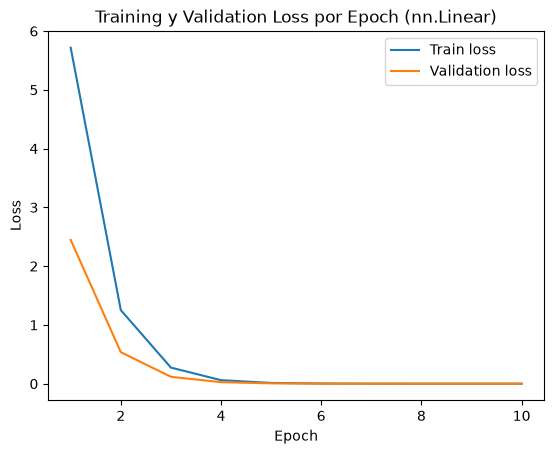

In [11]:
torch.manual_seed(SEED)  # mismo orden de shuffle que la corrida a mano

num_epochs = 10

train_losses_nn, val_losses_nn = [], []

for epoch in range(1, num_epochs + 1):
    model_nn.train()
    total_train, count_train = 0.0, 0
    for Xb, yb in train_loader:
        y_hat = model_nn(Xb)
        loss = loss_fn(y_hat, yb)
        optim_nn.zero_grad()
        loss.backward()
        optim_nn.step()
        total_train += loss.item() * yb.shape[0]
        count_train += yb.shape[0]

    train_losses_nn.append(total_train / count_train)

    model_nn.eval()
    total_val, count_val = 0.0, 0
    with torch.no_grad():
        for Xv, yv in val_loader:
            loss_val = loss_fn(model_nn(Xv), yv)
            total_val += loss_val.item() * yv.shape[0]
            count_val += yv.shape[0]

    val_losses_nn.append(total_val / count_val)


with torch.no_grad():
    est_w = model_nn.weight.reshape(true_w.shape)
    est_b = model_nn.bias

    print("Error en w: ", true_w - est_w)
    print("Error en b: ", true_b - est_b)

plt.plot(range(1, num_epochs + 1), train_losses_nn, label='Train loss')
plt.plot(range(1, num_epochs + 1), val_losses_nn, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training y Validation Loss por Epoch (nn.Linear)')
plt.show()    

#### Comparación (1c)

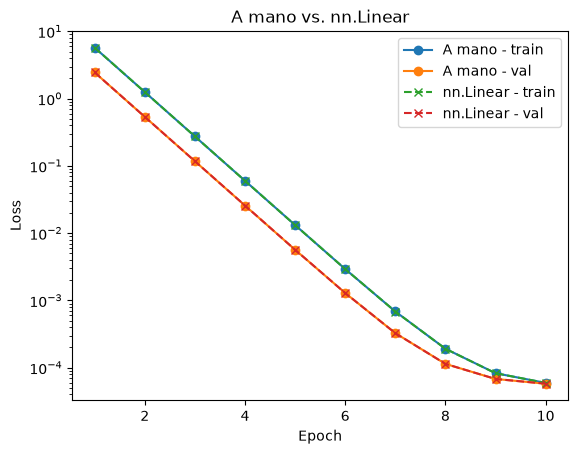

                       w           b      val loss
Real             2.00000     4.20000             -
A mano           1.99907     4.19755     5.785e-05
nn.Linear        1.99907     4.19755     5.785e-05
max |diff| de parametros: 7.152557373046875e-07


In [12]:
epochs = range(1, num_epochs + 1)

plt.plot(epochs, train_losses, 'o-', label='A mano - train')
plt.plot(epochs, val_losses, 'o-', label='A mano - val')
plt.plot(epochs, train_losses_nn, 'x--', label='nn.Linear - train')
plt.plot(epochs, val_losses_nn, 'x--', label='nn.Linear - val')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('A mano vs. nn.Linear')
plt.show()

with torch.no_grad():
    print(f"{'':12s}{'w':>12s}{'b':>12s}{'val loss':>14s}")
    print(f"{'Real':12s}{true_w.item():12.5f}{true_b:12.5f}{'-':>14s}")
    print(f"{'A mano':12s}{model.w.item():12.5f}{model.b.item():12.5f}{val_losses[-1]:14.3e}")
    print(f"{'nn.Linear':12s}{model_nn.weight.item():12.5f}{model_nn.bias.item():12.5f}{val_losses_nn[-1]:14.3e}")
    print("max |diff| de parametros:",
          max((model.w - model_nn.weight.T).abs().max().item(), (model.b - model_nn.bias).abs().max().item()))


**Interpretación (1c)**

Para que la comparación fuera justa fijé la semilla (`SEED = 42`) en los datos, el split, la inicialización y el orden del shuffle, y igualé la inicialización (w ~ N(0, 0.01), b = 0) y la pérdida (`nn.MSELoss()/2`, equivalente a `(ŷ - y)²/2`).

**Resultado:** las dos implementaciones son numéricamente equivalentes. Obtienen los mismos parámetros (w ≈ 1.9991, b ≈ 4.1976), la misma pérdida de validación y curvas que se encimen. La diferencia máxima entre parámetros es ~7e-7, ruido de punto flotante.

**¿Cuál es la diferencia entonces?** Ninguna matemática: ambos modelos calculan `Xw + b`, minimizan el mismo MSE y usan SGD de minibatch. Las diferencias son de implementación:
- `nn.Linear` ya trae `weight` con forma `(out, in)`, `bias` e inicialización propia (Kaiming uniforme), y se usa con `torch.optim.SGD` y `nn.MSELoss`. Nuestra clase define todo esto a mano (parámetros `(in, 1)`, SGD con `p.data -= lr * p.grad`).
- La clase propia es útil para entender qué hace PyTorch por dentro. `nn.Linear` es lo que se usaría en la práctica.

**Por qué en la primera corrida parecían distintos:** sin semilla, los datos, el split y la inicialización cambiaban entre corridas. Además, `nn.MSELoss` no divide entre 2, así que con la misma lr su gradiente es el doble y converge más rápido. Por eso `nn.Linear` quedó más cerca del valor real en 10 épocas. Era un efecto de la pérdida y la inicialización, no de la implementación.

**Error residual:** el error de ~1e-3 que queda en w y b viene del ruido de los datos (σ = 0.01) y de las pocas épocas, no del modelo.

## Ejercicio 2

Se varía únicamente `batch_size` (n = tamaño del train set, 16, 32, 64). Mismos datos, mismo split, misma inicialización, misma lr (0.03) y mismas épocas.

**Hipótesis:** con batch completo (n) solo hay 1 actualización por época, así que convergerá mucho más lento por época pero con una curva suave. Con batches más chicos hay más actualizaciones por época (800/16 = 50, 800/32 = 25, 800/64 ≈ 13), por lo que convergerán más rápido y con curvas algo más ruidosas, siendo 16 el más ruidoso.

In [13]:
import time

def train_model(batch_size, num_epochs = 20, lr = 0.03):
    torch.manual_seed(SEED)
    m = LinearRegression(num_inputs = X.shape[1], lr = lr)
    opt = m.configure_optimizers()
    loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
    vloader = DataLoader(val_dataset, batch_size = len(val_dataset), shuffle = False)

    tr, va = [], []
    t0 = time.time()
    for epoch in range(num_epochs):
        total, count = 0.0, 0
        for Xb, yb in loader:
            loss = m.loss(m(Xb), yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * yb.shape[0]
            count += yb.shape[0]
        tr.append(total / count)

        with torch.no_grad():
            Xv, yv = next(iter(vloader))
            va.append(m.loss(m(Xv), yv).item())
    return m, tr, va, time.time() - t0

n = len(train_dataset)
batch_sizes = {'n (batch completo)': n, '64': 64, '32': 32, '16': 16}
results = {name: train_model(bs) for name, bs in batch_sizes.items()}

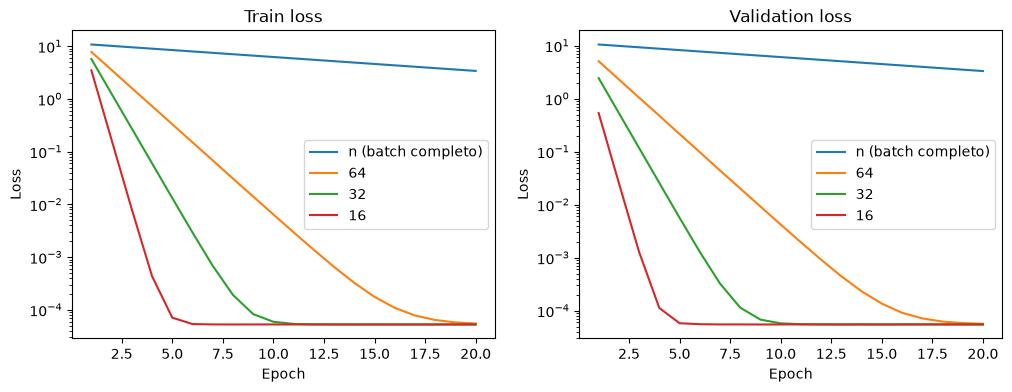

batch_size             updates/ep         w         b    val loss  tiempo (s)
n (batch completo)              1    0.9074    1.9139   3.319e+00        0.03
64                             13    1.9993    4.1982   5.658e-05        0.04
32                             25    2.0001    4.1997   5.510e-05        0.05
16                             50    2.0001    4.1998   5.513e-05        0.07
Real: w = 2.0, b = 4.2


In [14]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))
for name, (m, tr, va, _) in results.items():
    axes[0].plot(range(1, len(tr) + 1), tr, label = name)
    axes[1].plot(range(1, len(va) + 1), va, label = name)
for ax, title in zip(axes, ['Train loss', 'Validation loss']):
    ax.set_yscale('log')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(title)
    ax.legend()
plt.show()

print(f"{'batch_size':22s}{'updates/ep':>11s}{'w':>10s}{'b':>10s}{'val loss':>12s}{'tiempo (s)':>12s}")
for name, (m, tr, va, t) in results.items():
    bs = batch_sizes[name]
    print(f"{name:22s}{-(-n // bs):11d}{m.w.item():10.4f}{m.b.item():10.4f}{va[-1]:12.3e}{t:12.2f}")
print(f"Real: w = {true_w.item()}, b = {true_b}")

**Interpretación (Ejercicio 2)**

| batch_size | updates/época | val loss (20 épocas) |
|---|---|---|
| n = 800 | 1 | 3.3 (no converge) |
| 64 | 13 | 5.7e-05 |
| 32 | 25 | 5.5e-05 |
| 16 | 50 | 5.5e-05 |

**Velocidad de convergencia (por época):** es claramente monótona en el tamaño del batch: mientras más chico, más rápido. Con batch 16 la pérdida llega al piso en ~5 épocas, con 32 en ~10, con 64 en ~18, y con batch completo ni siquiera en 20 épocas (w = 0.91 y b = 1.91 vs. los reales 2 y 4.2). La razón es que el número de actualizaciones por época es n/batch_size (1, 13, 25, 50) y, con la misma lr, cada actualización avanza una cantidad similar. La comparación es por época, no por costo de cómputo: aquí el problema es tan pequeño que los tiempos son casi idénticos.

**Estabilidad:** mi hipótesis era que los batches chicos serían más ruidosos, pero **no se observa** en estas curvas. Las cuatro son suaves y terminan en el mismo piso, ~5.5e-05 ≈ σ²/2 (con σ = 0.01), el ruido irreducible de los datos. El problema es convexo, de 2 parámetros, con ruido muy pequeño y una lr baja (0.03), de modo que la varianza del gradiente de minibatch es insignificante. Aquí lo que domina es el número de pasos.

**Conclusión:** en este experimento el minibatch es mejor por época y el batch completo es el más lento con la misma lr. En la práctica, los minibatches dan un compromiso entre el ruido del gradiente y la eficiencia computacional, ventaja que no se ve en un problema convexo tan fácil.

# Ejercicio 3 

In [ ]:
# Matriz de diseño con columna de 1 para el sesgo: [X | 1]

X_train = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
y_train = torch.stack([train_dataset[i][1] for i in range(len(train_dataset))])


# Opción 1: torch.linalg.lstsq

sol = torch.linalg.lstsq(A, y)